In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import torch.optim as optim
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy.stats import t
import ast
from pathlib import Path

ANALYSE DU TEMPS

In [2]:
df_original = pd.read_csv("results/results_test_list_random_order.csv")

In [3]:
df_original["confusion_matrix"] = df_original["confusion_matrix"].apply(ast.literal_eval)
df_original = df_original.drop(['test_data_time', 'test_time'], axis=1)
df_original["network_time+load_time"] = df_original["load_time"] + df_original["network_time"]
df_original["total_time"] = df_original["network_time+load_time"] + df_original["forward_time"]
df_original["load_time+forward_time"] = df_original["load_time"] + df_original["forward_time"]

In [4]:
df_original.head()

,net_name,network_time,forward_time,load_time,accuracy,confusion_matrix,network_time+load_time,total_time,load_time+forward_time
0,dilated_lenet5,0.000888,0.277716,1.497419,98.94,"[[975, 0, 0, 0, 0, 0, 1, 1, 3, 0], [0, 1130, 1...",1.498307,1.776024,1.775136
1,400-300-10,0.002034,0.086717,1.295269,98.34,"[[973, 0, 1, 0, 0, 0, 2, 1, 2, 1], [0, 1122, 3...",1.297303,1.384020,1.381986
2,network3,0.005548,0.573622,1.305918,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1...",1.311467,1.885088,1.879540
3,dropout_CNN,0.001009,0.364291,1.560744,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0...",1.561752,1.926043,1.925035
4,128-10,0.000743,0.044912,1.267283,98.07,"[[970, 0, 1, 0, 0, 2, 2, 1, 3, 1], [0, 1123, 3...",1.268026,1.312938,1.312196


In [5]:
df_means = df_original[["net_name", "network_time", "forward_time", "load_time", "network_time+load_time", "load_time+forward_time","total_time", "accuracy"]].groupby("net_name").mean()

In [6]:
df_means

,network_time,forward_time,load_time,network_time+load_time,load_time+forward_time,total_time,accuracy
net_name,,,,,,,
128-10,0.000680,0.040027,1.195040,1.195720,1.235068,1.235748,98.07
400-10,0.001587,0.058547,1.202348,1.203935,1.260894,1.262481,98.35
400-300-10,0.001906,0.077256,1.200203,1.202109,1.277459,1.279365,98.34
CNN_with_BN,0.009390,0.811646,1.300128,1.309519,2.111774,2.121164,99.38
dilated_lenet5,0.000888,0.266199,1.473652,1.474540,1.739851,1.740740,98.94
dropout_CNN,0.001163,0.334438,1.481950,1.483113,1.816388,1.817551,99.37
dropout_lenet5,0.001067,0.274277,1.475977,1.477044,1.750254,1.751321,99.19
lenet1,0.000492,0.193061,1.690783,1.691275,1.883843,1.884335,98.44
lenet4,0.000825,0.232181,1.457211,1.458037,1.689392,1.690217,99.09


In [7]:
alpha = 0.05

numeric_cols = df_original.select_dtypes(include=np.number).columns

results = {}

for col in numeric_cols:
    ic_list = []

    for net_name, group in df_original.groupby("net_name"):
        n = len(group)
        s = group[col].std(ddof=1)

        # quantile de Student
        t_crit = t.ppf(1 - alpha / 2, df=n - 1)

        margin = t_crit * s / np.sqrt(n)

        ic_list.append(margin)

    results[col] = ic_list

df_ic = pd.DataFrame(results, index = df_original["net_name"].unique())

In [8]:
df_ic

,network_time,forward_time,load_time,accuracy,network_time+load_time,total_time,load_time+forward_time
dilated_lenet5,0.000064,0.001827,0.030050,1.071573e-14,0.030063,0.031802,0.031789
400-300-10,0.000230,0.002102,0.028509,0.000000e+00,0.028610,0.030464,0.030365
network3,0.000192,0.003069,0.031035,0.000000e+00,0.031071,0.033851,0.033819
dropout_CNN,0.002354,0.011847,0.020038,0.000000e+00,0.020695,0.030984,0.030427
128-10,0.000173,0.005256,0.024315,1.071573e-14,0.024281,0.028320,0.028349
lenet1,0.000112,0.011474,0.030672,0.000000e+00,0.030651,0.041591,0.041614
simplified_lenet5,0.000111,0.007163,0.045337,1.071573e-14,0.045328,0.051431,0.051444
dropout_lenet5,0.000038,0.005269,0.028048,1.071573e-14,0.028065,0.031871,0.031856
lenet4,0.000173,0.007150,0.028953,0.000000e+00,0.028931,0.035227,0.035248
lenet5,0.000084,0.005459,0.021382,0.000000e+00,0.021419,0.026081,0.026045


In [9]:
def pareto_front(df, time_feature):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if (
                other['accuracy'] >= row['accuracy'] and
                other[time_feature] <= row[time_feature] and
                (other['accuracy'] > row['accuracy'] or
                 other[time_feature] < row[time_feature])
            ):
                dominated = True
                break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

In [10]:
def plot_time_vs_accuracy(time_feature):
    plt.figure(figsize=(10, 6))
    plt.scatter(df_means[time_feature], df_means["accuracy"], color="tab:blue", s=80)

    #nommage des points
    for net_name, row in df_means.iterrows():
        plt.annotate(net_name,
                    (row[time_feature], row["accuracy"]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    ha="left",
                    fontsize=9)

    #intervalles de confiance
    plt.errorbar(
        df_means[time_feature],
        df_means["accuracy"],
        xerr= df_ic[time_feature],
        fmt='none',
        capsize=4
    )

    #courbe de pareto
    pareto_df = pareto_front(df_means, time_feature)
    pareto_df = pareto_df.sort_values(time_feature)
    plt.plot(pareto_df[time_feature], pareto_df['accuracy'], color='red', label="Front de Pareto")

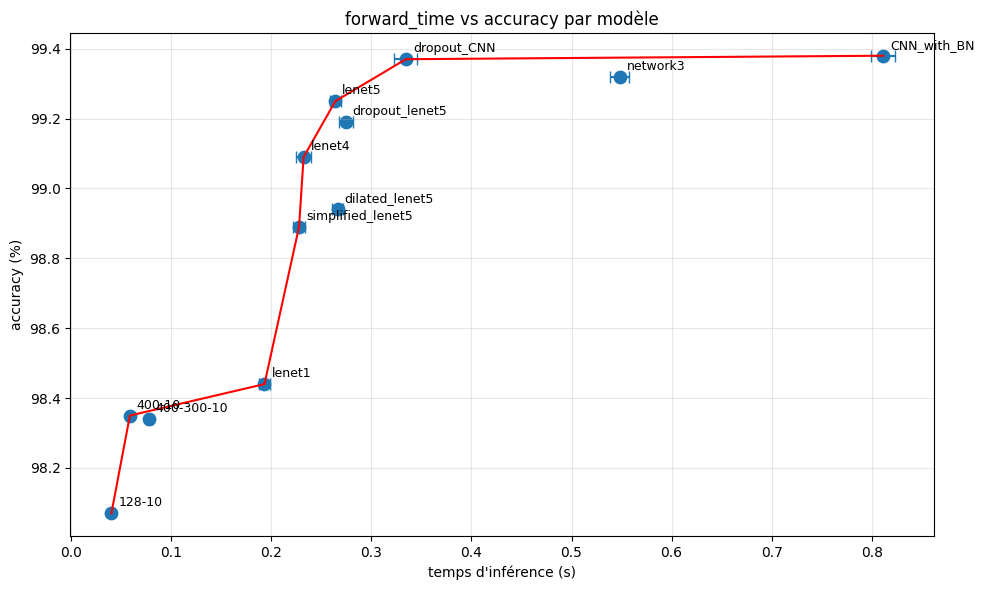

In [11]:
plot_time_vs_accuracy("forward_time")
plt.title("forward_time vs accuracy par modèle")
plt.xlabel("temps d'inférence (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

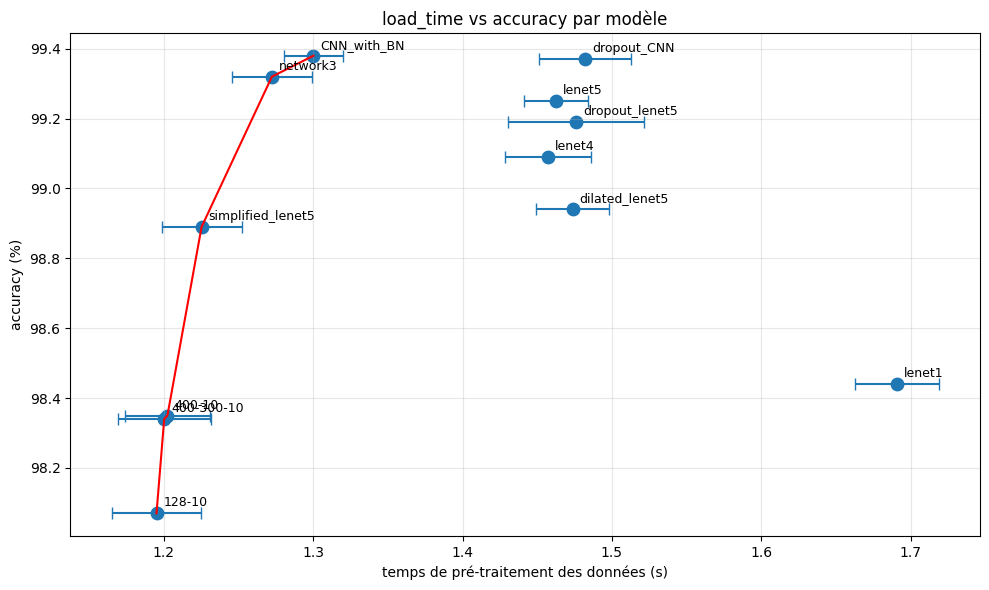

In [12]:
plot_time_vs_accuracy("load_time")
plt.title("load_time vs accuracy par modèle")
plt.xlabel("temps de pré-traitement des données (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

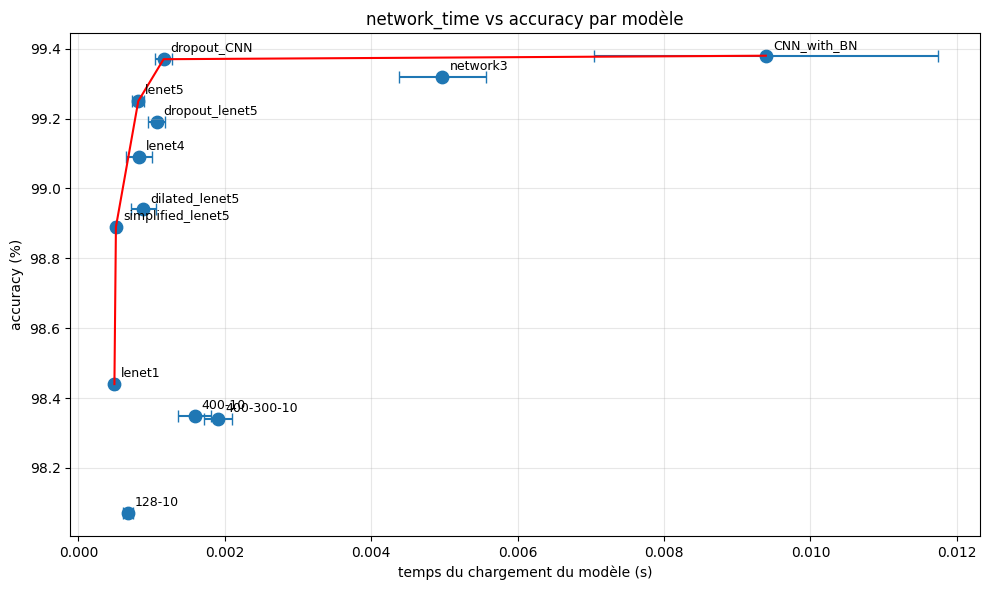

In [13]:
plot_time_vs_accuracy("network_time")
plt.title("network_time vs accuracy par modèle")
plt.xlabel("temps du chargement du modèle (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

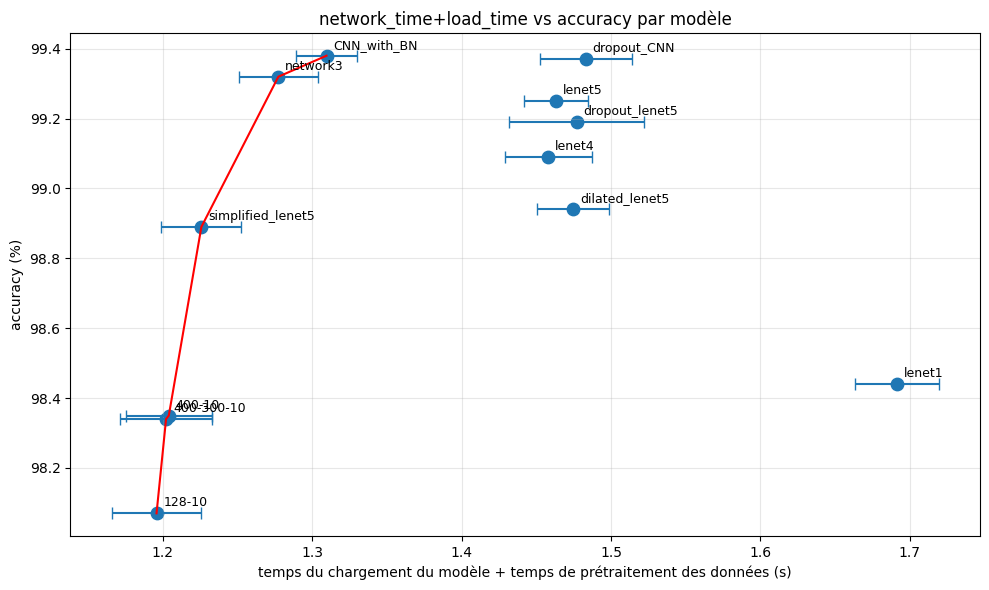

In [14]:
plot_time_vs_accuracy("network_time+load_time")
plt.title("network_time+load_time vs accuracy par modèle")
plt.xlabel("temps du chargement du modèle + temps de prétraitement des données (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

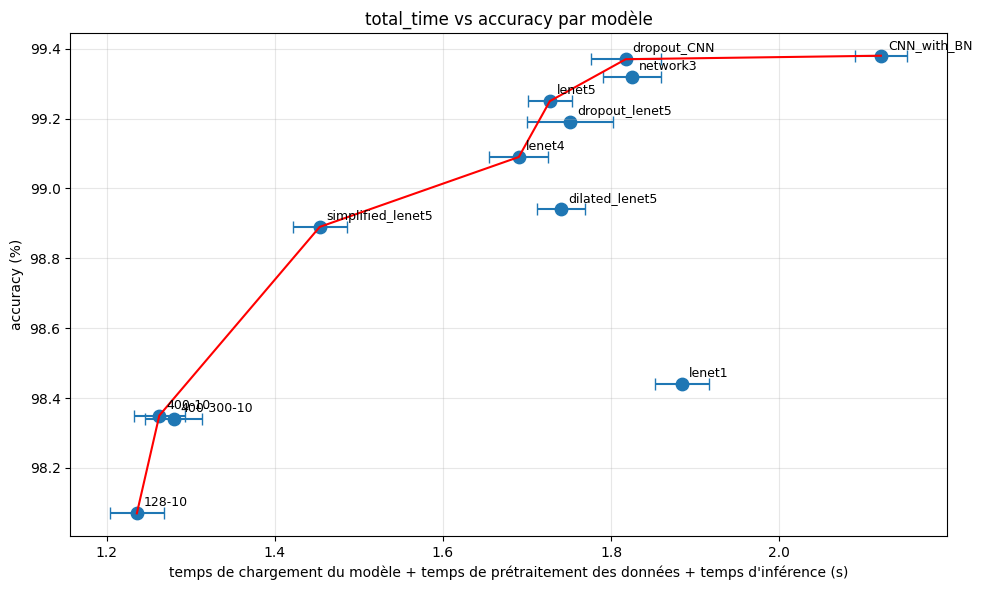

In [15]:
plot_time_vs_accuracy("total_time")
plt.title("total_time vs accuracy par modèle")
plt.xlabel("temps de chargement du modèle + temps de prétraitement des données + temps d'inférence (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

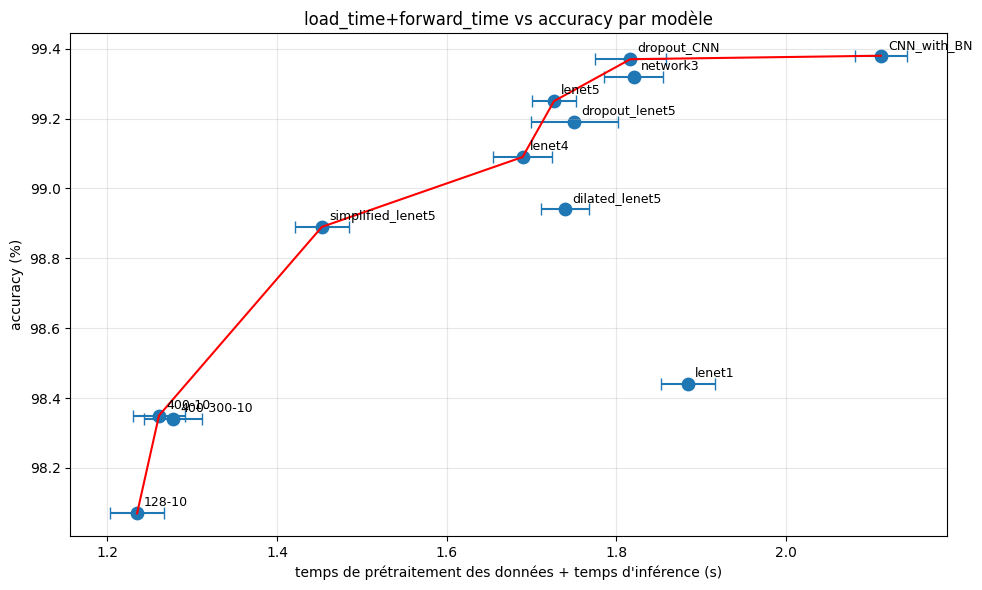

In [16]:
plot_time_vs_accuracy("load_time+forward_time")
plt.title("load_time+forward_time vs accuracy par modèle")
plt.xlabel("temps de prétraitement des données + temps d'inférence (s)")
plt.ylabel("accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

CLASSEMENTS

In [17]:
results = []

for net_name in df_means.index:
    file = Path("params/"+net_name+".pt")

    try:
        obj = torch.load(file, map_location="cpu")

        # Cas 1 : checkpoint contenant model_state_dict
        if isinstance(obj, dict) and "model_state_dict" in obj:
            state_dict = obj["model_state_dict"]

        # Cas 2 : state_dict directement sauvegardé
        elif isinstance(obj, dict):
            state_dict = obj

        else:
            raise ValueError(f"Format inattendu : {type(obj)}")

        # Ne garder que les tenseurs
        tensors = [v for v in state_dict.values()
                   if isinstance(v, torch.Tensor)]

        n_params = sum(t.numel() for t in tensors)

        size_mb = file.stat().st_size / (1024 ** 2)

        results.append({
            "net_name": file.stem,
            "fichier": file.name,
            "taille_(Mo)": round(size_mb, 2),
            "nb_parametres": n_params,
        })


    except Exception as e:
        print(f"  ERREUR : {e}")

        results.append({
            "net_name": file.stem,
            "fichier": file.name,
            "taille_(Mo)": None,
            "nb_parametres": None,
            "Erreur": str(e)
        })

df_size = pd.DataFrame(results)
df_size = df_size.set_index("net_name")
display(df_size.sort_values('taille_(Mo)', ascending=True))

,fichier,taille_(Mo),nb_parametres
net_name,,,
lenet1,lenet1.pt,0.02,3246
simplified_lenet5,simplified_lenet5.pt,0.03,5994
lenet4,lenet4.pt,0.20,51050
dilated_lenet5,dilated_lenet5.pt,0.24,61706
dropout_lenet5,dropout_lenet5.pt,0.24,61706
lenet5,lenet5.pt,0.24,61706
128-10,128-10.pt,0.39,101770
dropout_CNN,dropout_CNN.pt,0.61,158488
400-10,400-10.pt,1.22,318010


In [18]:
network_time_sorted = df_means.sort_values('network_time', ascending=True).index.tolist()
forward_time_sorted = df_means.sort_values('forward_time', ascending=True).index.tolist()
load_time_sorted = df_means.sort_values('load_time', ascending=True).index.tolist()
nb_parameters_sorted = df_size.sort_values('nb_parametres', ascending=True).index.tolist()

ranking_df = pd.DataFrame({
    'Rang': range(1, 13),
    'Network Time': network_time_sorted,
    'Forward Time': forward_time_sorted,
    'Load Time': load_time_sorted,
    'Nb Parametres' : nb_parameters_sorted
})

def style_dataframe(df):
    
    unique_names = set(df['Network Time'].tolist() + df['Forward Time'].tolist() + df['Load Time'].tolist() + df['Nb Parametres'].tolist())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_names)))
    color_map = {name: mcolors.to_hex(color) for name, color in zip(sorted(unique_names), colors)}
    
    # Fonction pour appliquer les couleurs
    def apply_colors(val):
        if val == 'Rang':
            return 'background-color: #f0f0f0'
        if pd.isna(val):
            return ''
        hex_color = color_map.get(val, '#ffffff')
        return f'background-color: {hex_color}; color: black; font-weight: bold'
    
    styled = df.style.map(apply_colors)
    styled.set_properties(**{'text-align': 'center', 'padding': '8px'})
    
    return styled

style_dataframe(ranking_df)

,Rang,Network Time,Forward Time,Load Time,Nb Parametres
0,1,lenet1,128-10,128-10,lenet1
1,2,simplified_lenet5,400-10,400-300-10,simplified_lenet5
2,3,128-10,400-300-10,400-10,lenet4
3,4,lenet5,lenet1,simplified_lenet5,dilated_lenet5
4,5,lenet4,simplified_lenet5,network3,dropout_lenet5
5,6,dilated_lenet5,lenet4,CNN_with_BN,lenet5
6,7,dropout_lenet5,lenet5,lenet4,128-10
7,8,dropout_CNN,dilated_lenet5,lenet5,dropout_CNN
8,9,400-10,dropout_lenet5,dilated_lenet5,400-10
9,10,400-300-10,dropout_CNN,dropout_lenet5,400-300-10


RAPPEL ET PRECISION

In [19]:
def precision_recall_par_classe(conf_matrix):

    precisions = []
    recalls = []
    n_classes = len(conf_matrix)
    
    for i in range(n_classes):
        # True Positive
        tp = conf_matrix[i][i]

        # False Negative
        fn = sum(conf_matrix[i]) - tp

        # False Positive
        fp = sum(conf_matrix[j][i] for j in range(n_classes)) - tp

        precision = tp / (tp + fp)
        recall = tp / (tp + fn)

        precisions.append(precision)
        recalls.append(recall)
    
    return precisions, recalls

In [20]:
def plot_precision_recall_hitmap(cm_series, vmin, vmax):

    resultats = []

    for net_name, cm in cm_series.items():
        precision, recall = precision_recall_par_classe(cm)

        for classe in range(10):
            resultats.append({
                "Modele": net_name,
                "Classe": classe,
                "Precision": precision[classe],
                "Recall": recall[classe]
            })

    df = pd.DataFrame(resultats)

    pivot_precision = df.pivot(
        index="Classe",
        columns="Modele",
        values="Precision"
    )

    pivot_recall = df.pivot(
        index="Classe",
        columns="Modele",
        values="Recall"
    )


    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ----- Precision -----
    im2 = axes[0].imshow(pivot_precision, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im2, ax=axes[0], label="Precision")

    axes[0].set_xticks(range(len(pivot_precision.columns)))
    axes[0].set_xticklabels(
        pivot_precision.columns,
        rotation=60
    )

    axes[0].set_yticks(range(10))
    axes[0].set_yticklabels(range(10))

    axes[0].set_xlabel("Modèles")
    axes[0].set_ylabel("Classe")
    axes[0].set_title("Precision par classe et par modèle")

    # ----- Recall -----
    im1 = axes[1].imshow(pivot_recall, vmin=vmin, vmax=vmax, aspect='auto')
    fig.colorbar(im1, ax=axes[1], label="Recall")

    axes[1].set_xticks(range(len(pivot_recall.columns)))
    axes[1].set_xticklabels(
        pivot_recall.columns,
        rotation=60
    )

    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels(range(10))

    axes[1].set_xlabel("Modèles")
    axes[1].set_ylabel("Classe")
    axes[1].set_title("Recall par classe et par modèle")

    # Ajuste automatiquement l'espacement
    plt.tight_layout()

    # Affichage final
    plt.show()

In [21]:
df_standard = pd.read_csv("results/results_standard.csv")
df_standard["confusion_matrix"] = df_standard["confusion_matrix"].apply(ast.literal_eval)
df_standard = df_standard.set_index("net_name")
df_standard

,network_time,test_data_time,forward_time,load_time,accuracy,confusion_matrix
net_name,,,,,,
network3,0.026343,0.040965,0.730075,1.322202,99.32,"[[978, 0, 0, 0, 0, 0, 1, 1, 0, 0], [0, 1132, 1..."
CNN_with_BN,0.010292,0.005257,0.843492,1.128347,99.38,"[[979, 0, 0, 0, 0, 0, 0, 1, 0, 0], [0, 1134, 0..."
dropout_CNN,0.001277,0.005817,0.339490,1.319072,99.37,"[[975, 0, 1, 0, 0, 0, 3, 1, 0, 0], [0, 1133, 0..."
dropout_lenet5,0.001235,0.005640,0.284503,1.296801,99.19,"[[978, 0, 0, 0, 0, 0, 0, 1, 1, 0], [0, 1131, 0..."
lenet5,0.000686,0.005935,0.300282,1.429869,99.25,"[[975, 0, 0, 0, 0, 0, 2, 2, 1, 0], [1, 1130, 0..."
lenet4,0.000798,0.005605,0.244551,1.299257,99.09,"[[977, 0, 0, 0, 0, 0, 1, 1, 1, 0], [1, 1132, 0..."
simplified_lenet5,0.000898,0.004651,0.251220,1.063913,98.89,"[[976, 1, 0, 0, 0, 0, 1, 0, 2, 0], [0, 1125, 1..."
dilated_lenet5,0.000669,0.005765,0.276190,1.310063,98.94,"[[975, 0, 0, 0, 0, 0, 1, 1, 3, 0], [0, 1130, 1..."
lenet1,0.000434,0.005762,0.200938,1.485375,98.44,"[[971, 1, 0, 0, 0, 2, 3, 1, 0, 2], [0, 1126, 1..."


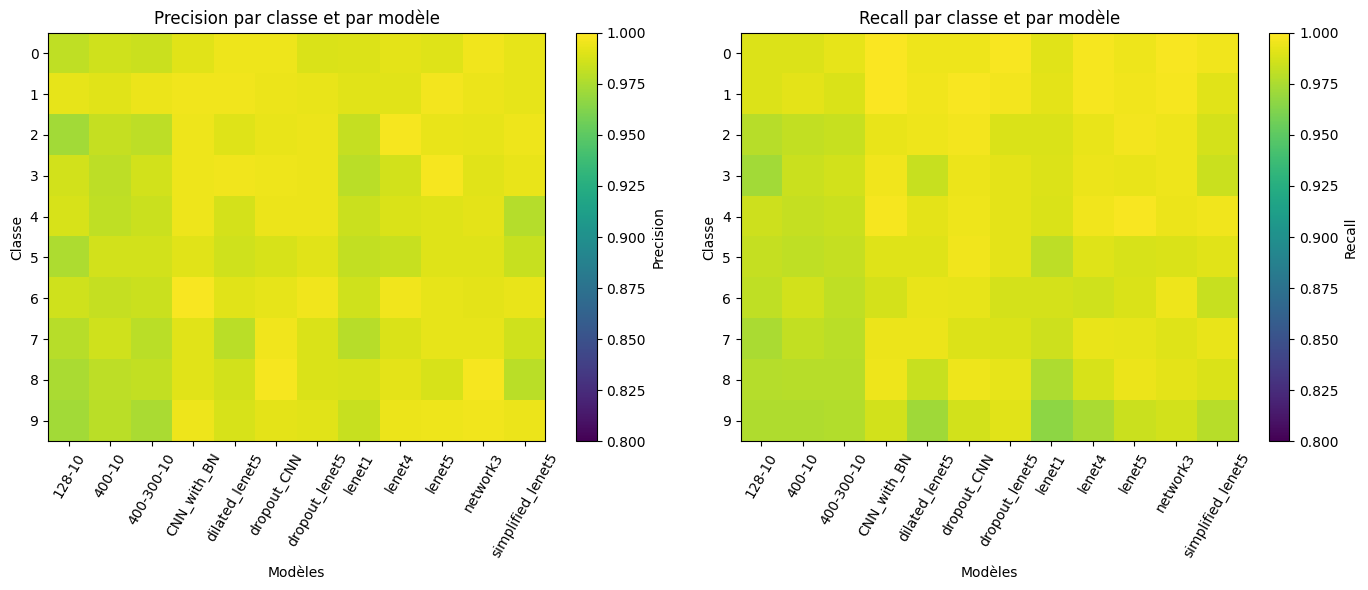

In [22]:
plot_precision_recall_hitmap(df_standard["confusion_matrix"], vmin = 0.8, vmax = 1.0)

In [23]:
def plot_precision_recall_combined(cm_series, vmin, vmax):
    resultats = []

    for net_name, cm in cm_series.items():
        precision, recall = precision_recall_par_classe(cm)
        for classe in range(10):
            resultats.append({
                "Modele": net_name,
                "Classe": classe,
                "Precision": precision[classe],
                "Recall": recall[classe]
            })

    df = pd.DataFrame(resultats)

    pivot_precision = df.pivot(index="Classe", columns="Modele", values="Precision")
    pivot_recall = df.pivot(index="Classe", columns="Modele", values="Recall")

    # Concaténer les deux matrices en colonnes adjacentes
    combined = pd.concat([
        pivot_precision.add_suffix("_Prec"),
        pivot_recall.add_suffix("_Rec")
    ], axis=1)

    # Intercaler Precision / Recall par modèle
    models = pivot_precision.columns.tolist()
    interleaved_cols = []
    for m in models:
        interleaved_cols.extend([f"{m}_Prec", f"{m}_Rec"])
    combined = combined[interleaved_cols]

    plt.figure(figsize=(16, 6))
    sns.heatmap(combined, cmap="viridis", vmin=vmin, vmax=vmax, cbar_kws={"label": "score"})
    plt.xticks(
        np.arange(combined.shape[1]) + 0.5,
        combined.columns,
        rotation=90,
        ha="center"
    )
    plt.yticks(np.arange(10) + 0.5, combined.index)
    plt.xlabel("Modèle / Métrique")
    plt.ylabel("Classe")
    plt.title("Precision et Recall par classe et par modèle")
    plt.tight_layout()
    plt.show()